In [4]:
import pandas as pd

In [5]:
from google.colab import files
uploaded = files.upload()

Saving gender_classification.csv to gender_classification.csv


In [7]:
df=pd.read_csv("gender_classification.csv")

In [8]:
df

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female
...,...,...,...,...,...,...,...,...
4996,1,13.6,5.1,0,0,0,0,Female
4997,1,11.9,5.4,0,0,0,0,Female
4998,1,12.9,5.7,0,0,0,0,Female
4999,1,13.2,6.2,0,0,0,0,Female


In [9]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 long_hair                    0
forehead_width_cm            0
forehead_height_cm           0
nose_wide                    0
nose_long                    0
lips_thin                    0
distance_nose_to_lip_long    0
gender                       0
dtype: int64


In [11]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 1768


In [13]:
df = df.drop_duplicates()

In [15]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [16]:
from sklearn.preprocessing import LabelEncoder

In [17]:
le = LabelEncoder()
df["gender"] = le.fit_transform(df["gender"])

/tmp/ipykernel_11640/3094290749.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["gender"] = le.fit_transform(df["gender"])


In [19]:
x = df.drop("gender", axis=1)
y = df["gender"]

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
log_reg = LogisticRegression()
log_reg.fit(x_train, y_train)

LogisticRegression()

In [27]:
#Model Evaluation
from sklearn.metrics import accuracy_score, classification_report

y_pred_log = log_reg.predict(x_test)
print("\nLogistic Regresssion Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log, target_names=["Female","Male"]))


Logistic Regresssion Results
Accuracy: 0.9556701030927836
              precision    recall  f1-score   support

      Female       0.96      0.95      0.95       457
        Male       0.96      0.96      0.96       513

    accuracy                           0.96       970
   macro avg       0.96      0.96      0.96       970
weighted avg       0.96      0.96      0.96       970



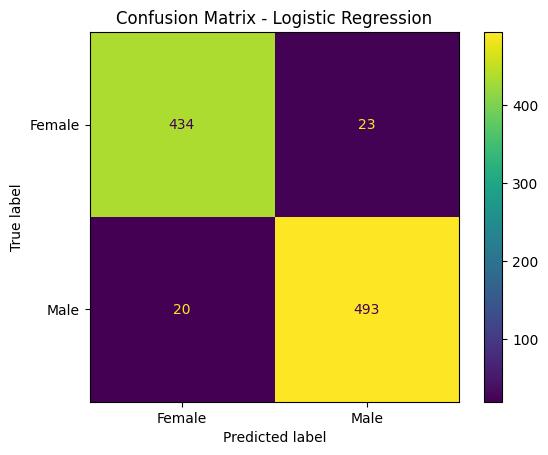

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Female", "Male"])
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [31]:
#External Prediction
new_data = [[0, 13.5, 6.2, 1, 1, 0, 1]]

new_data_df = pd.DataFrame(new_data, columns=x.columns)

log_result = log_reg.predict(new_data)[0]

print("Logistic Regression:", le.inverse_transform([log_result])[0])

Logistic Regression: Male


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
